In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

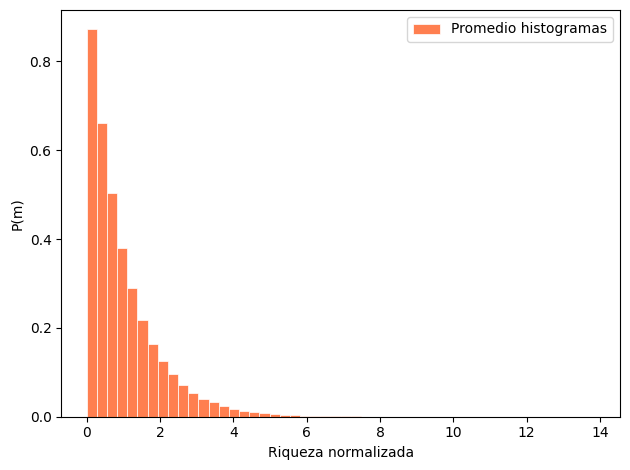

In [9]:
M = 5e4
N = 500
data = np.load('Pm_lamb0.0.npy') / (M/N)  # shape (N_simulations, 500)

# Definir bins fijos para que todos los histogramas sean comparables
bins = np.linspace(0, data.max(), 51)  # 50 bins, mismos para todos
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calcular histograma de cada simulación y apilarlos
densities = np.array([
    np.histogram(data[i], bins=bins, density=True)[0]
    for i in range(data.shape[0])
])

# Promediar bin a bin
density_mean = densities.mean(axis=0)

# Graficar
plt.bar(bin_centers, density_mean, width=np.diff(bins),
        color='coral', edgecolor='white', linewidth=0.5, label='Promedio histogramas')


plt.xlabel('Riqueza normalizada')
plt.ylabel('P(m)')
plt.legend()
plt.tight_layout()
plt.show()